In [ ]:
# Install latest versions (if running in Colab/Jupyter you may need !pip)
!pip install lightgbm catboost xgboost tabpfn

# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# Regression models
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

# New model TabPFN
from tabpfn import TabPFNRegressor


In [41]:
# Install lasio if not installed
!pip install lasio

import lasio
import pandas as pd

# Load LAS files
las7 = lasio.read("SAWAN-07.las.las")
las8 = lasio.read("SAWAN-08.las")
las1 = lasio.read("SAWAN-01.las")

# Convert to DataFrames
df7 = las7.df()
df8 = las8.df()
df1 = las1.df()

# Reset index (depth becomes a column)
df7.reset_index(inplace=True)
df8.reset_index(inplace=True)
df1.reset_index(inplace=True)

# Show heads to check logs
print("SAWAN-07 logs:\n", df7.head())
print("\nSAWAN-08 logs:\n", df8.head())
print("\nSAWAN-01 logs:\n", df1.head())


SAWAN-07 logs:
       DEPT  BS  C1  C2  CALI  CALS  CALS_2  CALS_3  CGR  CHRP  ...  THOR  \
0  49.4457 NaN NaN NaN   NaN   NaN     NaN     NaN  NaN   NaN  ...   NaN   
1  49.5707 NaN NaN NaN   NaN   NaN     NaN     NaN  NaN   NaN  ...   NaN   
2  49.6957 NaN NaN NaN   NaN   NaN     NaN     NaN  NaN   NaN  ...   NaN   
3  49.8207 NaN NaN NaN   NaN   NaN     NaN     NaN  NaN   NaN  ...   NaN   
4  49.9457 NaN NaN NaN   NaN   NaN     NaN     NaN  NaN   NaN  ...   NaN   

   TPRA  TURA  UPRA  UPRA_2  URAN  URAN_2  VSH_GR  VSH_GR1  VSH_ND  
0   NaN   NaN   NaN     NaN   NaN     NaN     NaN      NaN     NaN  
1   NaN   NaN   NaN     NaN   NaN     NaN     NaN      NaN     NaN  
2   NaN   NaN   NaN     NaN   NaN     NaN     NaN      NaN     NaN  
3   NaN   NaN   NaN     NaN   NaN     NaN     NaN      NaN     NaN  
4   NaN   NaN   NaN     NaN   NaN     NaN     NaN      NaN     NaN  

[5 rows x 63 columns]

SAWAN-08 logs:
       DEPT  BS  C1  C2  CALI    CALS  CGR  DRHO  DT4P  DT4S  ...  POTA  R

In [38]:
df8.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22347 entries, 0 to 22346
Data columns (total 29 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   DEPT    22347 non-null  float64
 1   BS      20740 non-null  float64
 2   C1      9137 non-null   float64
 3   C2      9137 non-null   float64
 4   CALI    2220 non-null   float64
 5   CALS    11170 non-null  float64
 6   CGR     2220 non-null   float64
 7   DRHO    2220 non-null   float64
 8   DT4P    2151 non-null   float64
 9   DT4S    2151 non-null   float64
 10  DTCO    20540 non-null  float64
 11  DTSM    2151 non-null   float64
 12  GR      22297 non-null  float64
 13  HDAR    20740 non-null  float64
 14  LLD     20521 non-null  float64
 15  LLS     20521 non-null  float64
 16  MSFL    2623 non-null   float64
 17  NPHI    2220 non-null   float64
 18  PEF     2220 non-null   float64
 19  POTA    2220 non-null   float64
 20  RHOB    2220 non-null   float64
 21  SGR     2220 non-null   float64
 22

In [42]:
# Drop accidental "level_0" if it exists
for d in [df7, df8, df1]:
    if 'level_0' in d.columns:
        d.drop(columns=['level_0'], inplace=True)

# Standardize column names (remove spaces, make uppercase)
def clean_columns(df):
    df.columns = df.columns.str.strip().str.upper()
    return df

df7 = clean_columns(df7)
df8 = clean_columns(df8)
df1 = clean_columns(df1)

# Rename for consistency
df7.rename(columns={'RHOB': 'RHOB'}, inplace=True)  # SAWAN-07
df1.rename(columns={'DT': 'DT4P'}, inplace=True)       # SAWAN-01

# Define features and target
features = ['DT4P', 'LLD', 'NPHI', 'PEF', 'RHOB', 'GR']
target = 'DT4S'

# Select only required logs
df7 = df7[['DEPT'] + features + [target]]
df8 = df8[['DEPT'] + features + [target]]
df1 = df1[['DEPT'] + features]   # no DT4S in SAWAN-01

# Add WELL name column
df7['WELL'] = 'SAWAN-07'
df8['WELL'] = 'SAWAN-08'
df1['WELL'] = 'SAWAN-01'

# Combine into single DataFrame
df_all = pd.concat([df7, df8, df1], ignore_index=True)

print("✅ Final Combined DataFrame shape:", df_all.shape)
print(df_all.head(10))



✅ Final Combined DataFrame shape: (77195, 9)
      DEPT  DT4P  LLD  NPHI  PEF  RHOB       GR  DT4S      WELL
0  49.4457   NaN  NaN   NaN  NaN   NaN  44.2871   NaN  SAWAN-07
1  49.5707   NaN  NaN   NaN  NaN   NaN  44.1347   NaN  SAWAN-07
2  49.6957   NaN  NaN   NaN  NaN   NaN  42.0807   NaN  SAWAN-07
3  49.8207   NaN  NaN   NaN  NaN   NaN  41.0876   NaN  SAWAN-07
4  49.9457   NaN  NaN   NaN  NaN   NaN  41.3085   NaN  SAWAN-07
5  50.0707   NaN  NaN   NaN  NaN   NaN  41.8350   NaN  SAWAN-07
6  50.1957   NaN  NaN   NaN  NaN   NaN  41.6947   NaN  SAWAN-07
7  50.3207   NaN  NaN   NaN  NaN   NaN  40.4748   NaN  SAWAN-07
8  50.4457   NaN  NaN   NaN  NaN   NaN  43.7629   NaN  SAWAN-07
9  50.5707   NaN  NaN   NaN  NaN   NaN  45.1492   NaN  SAWAN-07


/tmp/ipython-input-16134835.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['WELL'] = 'SAWAN-01'


In [13]:
print("SAWAN-07 columns:", df7.columns.tolist())
print("SAWAN-08 columns:", df8.columns.tolist())
print("SAWAN-01 columns:", df1.columns.tolist())


SAWAN-07 columns: ['index', 'DEPT', 'BS', 'C1', 'C2', 'CALI', 'CALS:1', 'CALS:2', 'CALS:3', 'CGR', 'CHRP', 'CHRS', 'CHTP', 'CHTS', 'DEVI', 'DPHI', 'DRHO', 'DT4P', 'DT4S', 'DTRP', 'DTRS', 'DTTP', 'DTTS', 'GR', 'HDAR', 'LLD', 'LLS', 'MSFL:1', 'MSFL:2', 'MSFL:3', 'MSFL:4', 'NPHI', 'PEF', 'POTA', 'RCAL', 'RHOB:1', 'RHOB:2', 'SGR', 'SP', 'THOR', 'TPRA', 'TURA', 'UPRA:1', 'UPRA:2', 'URAN:1', 'URAN:2']
SAWAN-08 columns: ['index', 'DEPT', 'BS', 'C1', 'C2', 'CALI', 'CALS', 'CGR', 'DRHO', 'DT4P', 'DT4S', 'DTCO', 'DTSM', 'GR', 'HDAR', 'LLD', 'LLS', 'MSFL', 'NPHI', 'PEF', 'POTA', 'RHOB', 'SGR', 'SP', 'THOR', 'TNPH', 'TPRA', 'TURA', 'UPRA', 'URAN']
SAWAN-01 columns: ['index', 'DEPT', 'C1', 'C2', 'CALI', 'CALS', 'CGR', 'DRHO', 'DT4P', 'DTL', 'DTLF', 'DTLN', 'GR', 'LLD', 'LLS', 'MSFL', 'NPHI', 'PEF', 'POTA', 'RHOB', 'SGR', 'SP', 'THOR', 'URAN']


In [19]:
df7.rename(columns={'RHOB:01': 'RHOB', 'DT': 'DT4P'}, inplace=True)


In [24]:
df7.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26892 entries, 0 to 26891
Data columns (total 46 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   INDEX   26892 non-null  int64  
 1   DEPT    26892 non-null  float64
 2   BS      24827 non-null  float64
 3   C1      2159 non-null   float64
 4   C2      2159 non-null   float64
 5   CALI    2924 non-null   float64
 6   CALS:1  11129 non-null  float64
 7   CALS:2  8202 non-null   float64
 8   CALS:3  2924 non-null   float64
 9   CGR     2924 non-null   float64
 10  CHRP    24843 non-null  float64
 11  CHRS    24843 non-null  float64
 12  CHTP    24843 non-null  float64
 13  CHTS    24843 non-null  float64
 14  DEVI    2159 non-null   float64
 15  DPHI    2924 non-null   float64
 16  DRHO    2924 non-null   float64
 17  DT4P    24797 non-null  float64
 18  DT4S    19879 non-null  float64
 19  DTRP    24744 non-null  float64
 20  DTRS    18872 non-null  float64
 21  DTTP    24747 non-null  float64
 22

In [43]:
# Define features and target
features = ['DT4P', 'LLD', 'NPHI', 'PEF', 'RHOB', 'GR']
target   = 'DT4S'

# Keep only features + target (and depth for tracking)
df7 = df7[['DEPT'] + features + [target]]
df8 = df8[['DEPT'] + features + [target]]
df1 = df1[['DEPT'] + features]   # no target in blind well

# Add well column
df7['WELL'] = 'SAWAN-07'
df8['WELL'] = 'SAWAN-08'
df1['WELL'] = 'SAWAN-01'

# Combine into single DataFrame
df_all = pd.concat([df7, df8, df1], ignore_index=True)

print("✅ Final DataFrame shape:", df_all.shape)
print(df_all.head())


✅ Final DataFrame shape: (77195, 9)
      DEPT  DT4P  LLD  NPHI  PEF  RHOB       GR  DT4S      WELL
0  49.4457   NaN  NaN   NaN  NaN   NaN  44.2871   NaN  SAWAN-07
1  49.5707   NaN  NaN   NaN  NaN   NaN  44.1347   NaN  SAWAN-07
2  49.6957   NaN  NaN   NaN  NaN   NaN  42.0807   NaN  SAWAN-07
3  49.8207   NaN  NaN   NaN  NaN   NaN  41.0876   NaN  SAWAN-07
4  49.9457   NaN  NaN   NaN  NaN   NaN  41.3085   NaN  SAWAN-07


In [52]:
import pandas as pd
import numpy as np

# Features and target
features = ['DT4P', 'LLD', 'NPHI', 'PEF', 'RHOB', 'GR']
target   = 'DT4S'

def preprocess_well(df, well_name):
    print(f"\n🛠 Preprocessing {well_name}")

    # Drop extra index if exists
    if df.columns[0].lower() in ["index", "level_0"]:
        df = df.drop(columns=df.columns[0])

    # Select only useful columns
    cols = features + ([target] if target in df.columns else [])
    df = df[cols].copy()

    # ----------------------
    # 1. Handle Missing Values
    # ----------------------
    before_missing = len(df)
    df = df.dropna()   # Simple approach: remove missing rows
    after_missing = len(df)
    print(f"   Missing values removed: {before_missing - after_missing}")

    # ----------------------
    # 2. Handle Outliers
    # ----------------------
    def remove_outliers_iqr(data, col):
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        return data[(data[col] >= lower) & (data[col] <= upper)]

    before_outliers = len(df)
    for col in cols:
        df = remove_outliers_iqr(df, col)
    after_outliers = len(df)
    print(f"   Outliers removed: {before_outliers - after_outliers}")

    # ----------------------
    # Final Cleaned Dataset
    # ----------------------
    print(f"   Final shape: {df.shape}")
    return df


# ✅ Run preprocessing on each well
df7_clean = preprocess_well(df7, "SAWAN-07")
df8_clean = preprocess_well(df8, "SAWAN-08")
df1_clean = preprocess_well(df1, "SAWAN-01")



🛠 Preprocessing SAWAN-07
   Missing values removed: 24686
   Outliers removed: 199
   Final shape: (2007, 7)

🛠 Preprocessing SAWAN-08
   Missing values removed: 20215
   Outliers removed: 348
   Final shape: (1784, 7)

🛠 Preprocessing SAWAN-01
   Missing values removed: 24258
   Outliers removed: 732
   Final shape: (2966, 6)


/tmp/ipython-input-869628464.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="Model", y=metric, palette="Spectral")
/tmp/ipython-input-869628464.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="Model", y=metric, palette="Spectral")
/tmp/ipython-input-869628464.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="Model", y=metric, palette="Spectral")


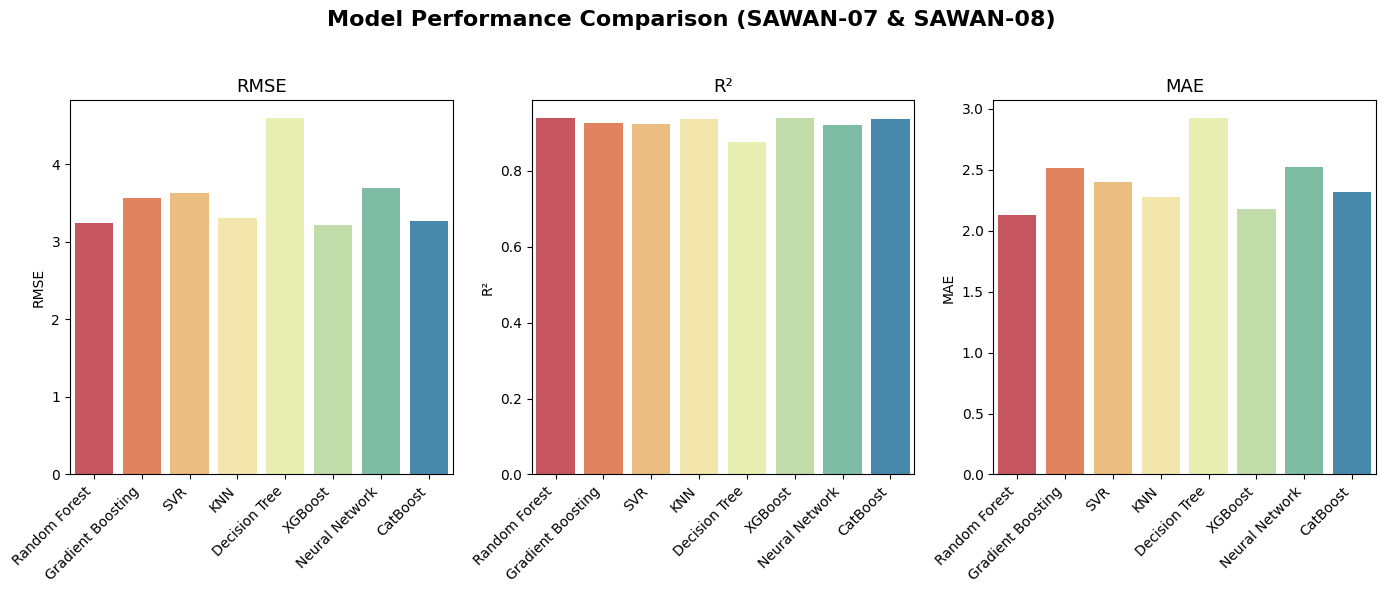

,Model,RMSE,R²,MAE
0,Random Forest,3.238237,0.938422,2.125582
1,Gradient Boosting,3.564931,0.925371,2.509951
2,SVR,3.627677,0.922720,2.395042
3,KNN,3.307683,0.935753,2.272004
4,Decision Tree,4.595054,0.876009,2.922731
5,XGBoost,3.219834,0.939120,2.178512
6,Neural Network,3.688340,0.920114,2.521869
7,CatBoost,3.273726,0.937065,2.317857


from matplotlib import pyplot as plt
_df_0['index'].plot(kind='hist', bins=20, title='index')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_1['RMSE'].plot(kind='hist', bins=20, title='RMSE')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_2['R²'].plot(kind='hist', bins=20, title='R²')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_3['MAE'].plot(kind='hist', bins=20, title='MAE')
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_17['Model'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_17, x='RMSE', y='Model', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_18['Model'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_18, x='R²', y='Model', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_19['Model'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_19, x='MAE', y='Model', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# ML Models
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from sklearn.neural_network import MLPRegressor
from catboost import CatBoostRegressor   # <- Added CatBoost

# ✅ Features & Target
features = ['DT4P', 'LLD', 'NPHI', 'PEF', 'RHOB', 'GR']
target   = 'DT4S'

# ✅ Combine SAWAN-07 & SAWAN-08
train_df = pd.concat([df7_clean, df8_clean], axis=0)

X = train_df[features]
y = train_df[target]

# ✅ Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ✅ Feature scaling (for ML models that need it)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# ✅ Models dictionary (8 algorithms)
models = {
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=200, random_state=42),
    "SVR": SVR(kernel='rbf', C=100, gamma=0.1),
    "KNN": KNeighborsRegressor(n_neighbors=8),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "XGBoost": XGBRegressor(n_estimators=300, learning_rate=0.05, random_state=42),
    "Neural Network": MLPRegressor(hidden_layer_sizes=(64,64), max_iter=1000, random_state=42),
    "CatBoost": CatBoostRegressor(iterations=300, learning_rate=0.05, depth=6, verbose=0, random_state=42)
}

# ✅ Train & evaluate all models
results = []
for name, model in models.items():
    if name in ["SVR", "KNN", "Neural Network"]:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    mae  = mean_absolute_error(y_test, y_pred)

    results.append([name, rmse, r2, mae])

results_df = pd.DataFrame(results, columns=["Model", "RMSE", "R²", "MAE"])

# ✅ Visualization
plt.figure(figsize=(14,6))
metrics = ["RMSE", "R²", "MAE"]

for i, metric in enumerate(metrics):
    plt.subplot(1,3,i+1)
    sns.barplot(data=results_df, x="Model", y=metric, palette="Spectral")
    plt.xticks(rotation=45, ha="right")
    plt.title(metric, fontsize=13)
    plt.ylabel(metric)
    plt.xlabel("")

plt.suptitle("Model Performance Comparison (SAWAN-07 & SAWAN-08)", fontsize=16, weight="bold")
plt.tight_layout(rect=[0,0,1,0.95])
plt.show()

results_df


Best Model Selected: XGBoost


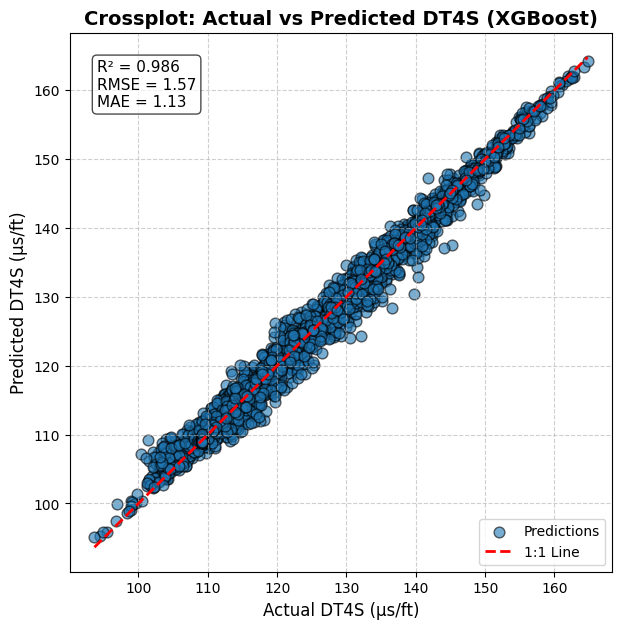

In [55]:
# ✅ Find best model from results_df
best_model_name = results_df.sort_values(by="RMSE").iloc[0]["Model"]
print("Best Model Selected:", best_model_name)

best_model = models[best_model_name]

# ✅ Retrain best model on full training wells (07+08)
if best_model_name in ["SVR", "KNN", "Neural Network"]:
    best_model.fit(scaler.fit_transform(X), y)
    X01_scaled = scaler.transform(df1_clean[features])
    y_pred_01 = best_model.predict(X01_scaled)
else:
    best_model.fit(X, y)
    y_pred_01 = best_model.predict(df1_clean[features])

# Add prediction column to SAWAN-01 DataFrame
df1_clean["DT4S_PRED"] = y_pred_01

# ✅ Crossplot: Actual vs Predicted (only for wells with DT4S, i.e., 07 & 08)
if best_model_name in ["SVR", "KNN", "Neural Network"]:
    y_pred_train = best_model.predict(scaler.transform(X))
else:
    y_pred_train = best_model.predict(X)

# Calculate metrics
rmse = np.sqrt(mean_squared_error(y, y_pred_train))
r2   = r2_score(y, y_pred_train)
mae  = mean_absolute_error(y, y_pred_train)

# ✅ Crossplot
plt.figure(figsize=(7,7))
plt.scatter(y, y_pred_train, alpha=0.6, edgecolor="k", s=60, label="Predictions")
plt.plot([y.min(), y.max()], [y.min(), y.max()], "r--", lw=2, label="1:1 Line")

# Formatting
plt.xlabel("Actual DT4S (µs/ft)", fontsize=12)
plt.ylabel("Predicted DT4S (µs/ft)", fontsize=12)
plt.title(f"Crossplot: Actual vs Predicted DT4S ({best_model_name})", fontsize=14, weight="bold")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)

# Annotate metrics
textstr = f"R² = {r2:.3f}\nRMSE = {rmse:.2f}\nMAE = {mae:.2f}"
plt.gca().text(0.05, 0.95, textstr, transform=plt.gca().transAxes,
               fontsize=11, verticalalignment="top",
               bbox=dict(boxstyle="round", facecolor="white", alpha=0.7))

plt.show()


In [71]:
# ✅ Predict DT4S for SAWAN-07
if best_model_name in ["SVR", "KNN", "Neural Network"]:
    X07_scaled = scaler.transform(df7_clean[features])
    df7_clean["DT4S_PRED"] = best_model.predict(X07_scaled)
else:
    df7_clean["DT4S_PRED"] = best_model.predict(df7_clean[features])

# ✅ Predict DT4S for SAWAN-08
if best_model_name in ["SVR", "KNN", "Neural Network"]:
    X08_scaled = scaler.transform(df8_clean[features])
    df8_clean["DT4S_PRED"] = best_model.predict(X08_scaled)
else:
    df8_clean["DT4S_PRED"] = best_model.predict(df8_clean[features])

print("✅ Predicted DT4S logs added to df7_clean and df8_clean")


✅ Predicted DT4S logs added to df7_clean and df8_clean


In [74]:
print(df8_clean.columns)

Index(['DT4P', 'LLD', 'NPHI', 'PEF', 'RHOB', 'GR', 'DT4S', 'DEPT',
       'DT4S_PRED'],
      dtype='object')


Using depth column: DEPT


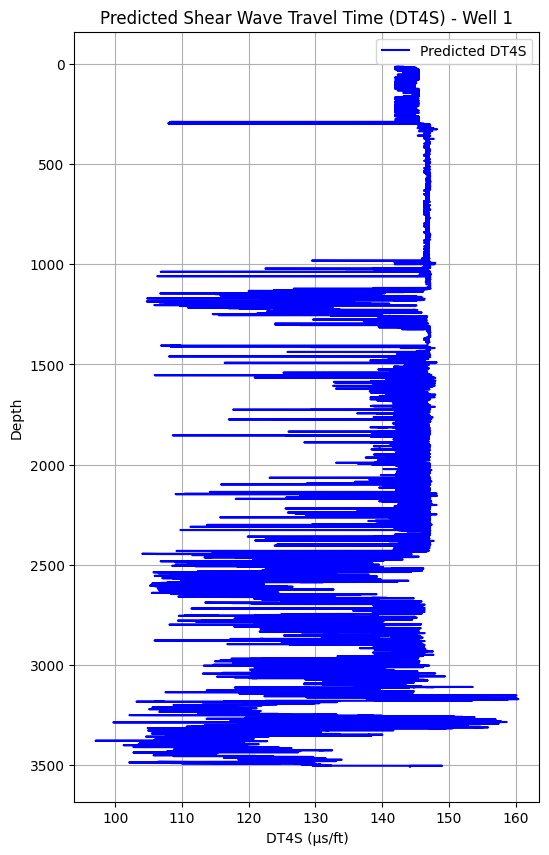

In [61]:
# --- Detect depth column safely ---
depth_col_candidates = ["DEPTH", "DEPT", "Depth", "depth"]
depth_col = None
for col in df1.columns:
    if col.strip() in depth_col_candidates:
        depth_col = col
        break

if depth_col is None:
    # fallback: assume second column is depth (index 1)
    depth_col = well1.columns[1]

print(f"Using depth column: {depth_col}")

# --- Features for Well-1 (same as training features) ---
X_well1 = df1[features]

# --- Predict DT4S ---
df1["DT4S_pred"] = best_model.predict(X_well1)

# --- Plot Predicted DT4S log for Well-1 ---
plt.figure(figsize=(6, 10))
plt.plot(df1["DT4S_pred"], df1[depth_col], label="Predicted DT4S", color="blue")

plt.gca().invert_yaxis()  # depth increases downward
plt.xlabel("DT4S (µs/ft)")
plt.ylabel("Depth")
plt.title("Predicted Shear Wave Travel Time (DT4S) - Well 1")
plt.legend()
plt.grid(True)
plt.show()


In [66]:
# Merge DEPT into cleaned versions by index alignment
df7_clean = df7_clean.copy()
df7_clean["DEPT"] = df7.loc[df7_clean.index, "DEPT"]

df8_clean = df8_clean.copy()
df8_clean["DEPT"] = df8.loc[df8_clean.index, "DEPT"]

df1_clean = df1_clean.copy()
df1_clean["DEPT"] = df1.loc[df1_clean.index, "DEPT"]



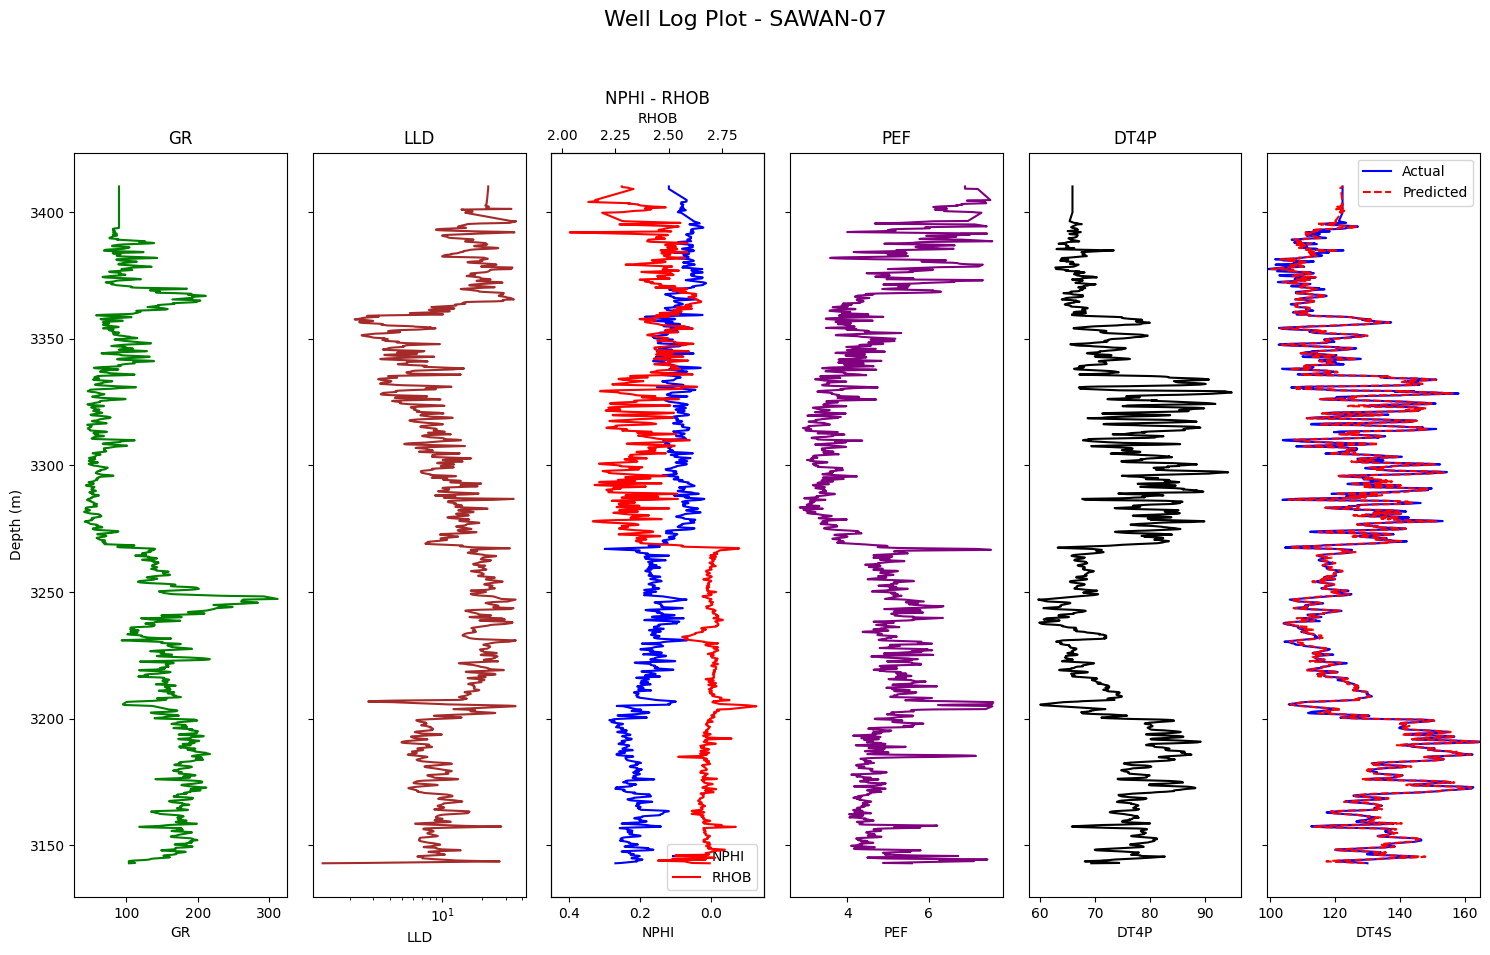

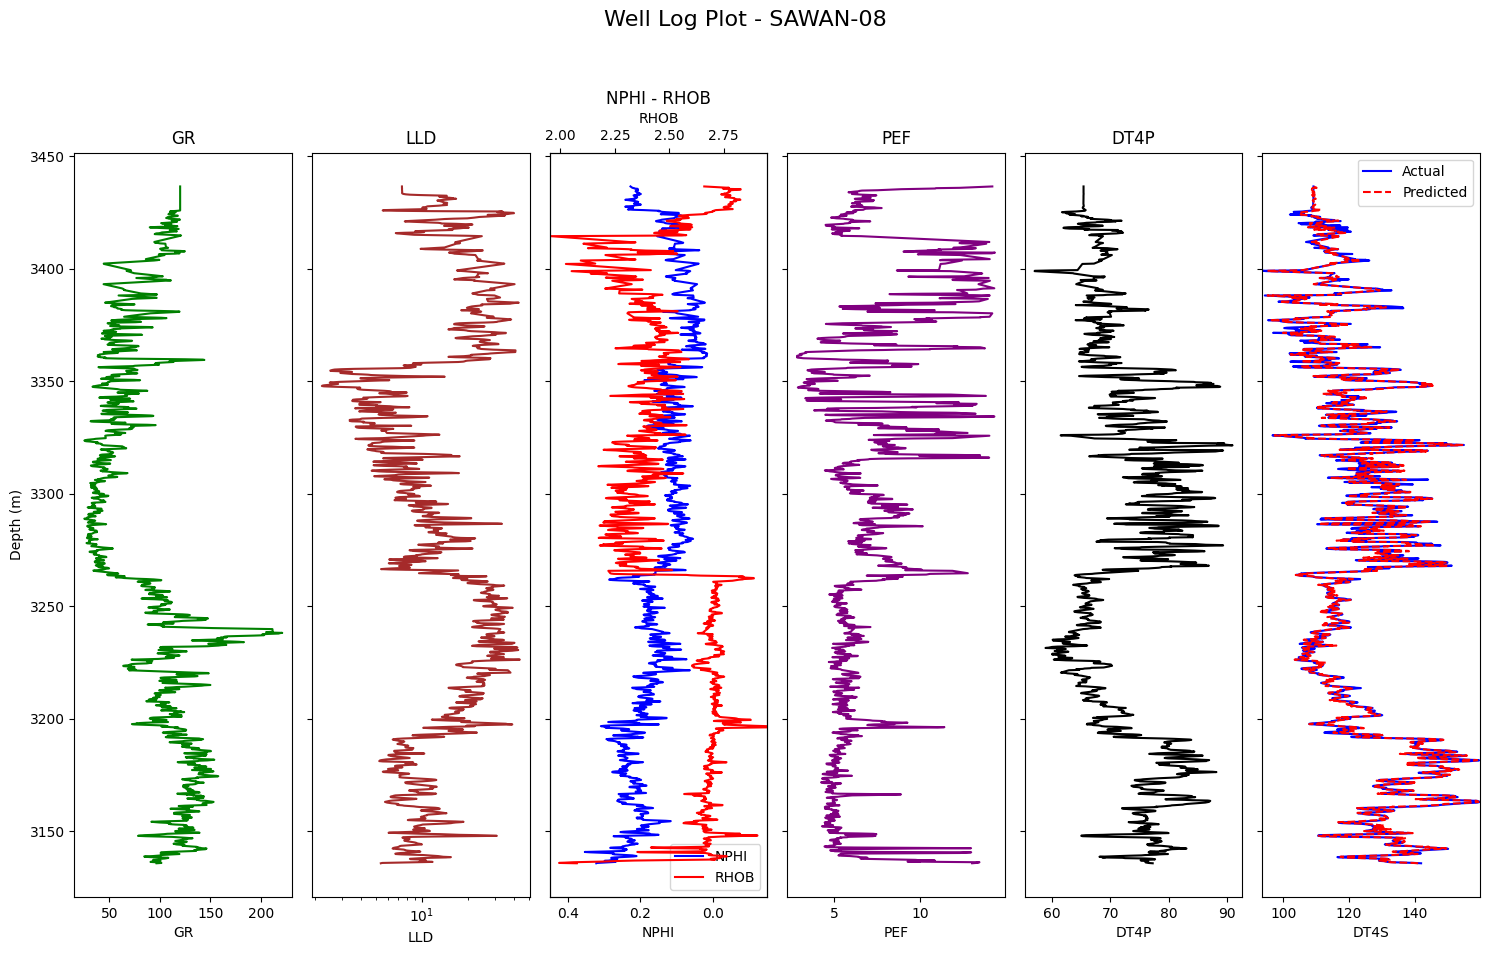

In [80]:
import matplotlib.pyplot as plt

def plot_logs(df, well_name):
    fig, axes = plt.subplots(nrows=1, ncols=6, figsize=(15,10), sharey=True)

    depth = df["DEPT"]

    # Track 1: GR
    axes[0].plot(df["GR"], depth, color="green")
    axes[0].set_xlabel("GR")
    axes[0].set_title("GR")
    axes[0].invert_yaxis()

    # Track 2: LLD (semi-log)
    axes[1].semilogx(df["LLD"], depth, color="brown")
    axes[1].set_xlabel("LLD")
    axes[1].set_title("LLD")

    # Track 3: NPHI with twin RHOB
    ax3 = axes[2]
    ax3.plot(df["NPHI"], depth, color="blue", label="NPHI")
    ax3.set_xlim(0.45, -0.15)  # neutron porosity scale
    ax3.set_xlabel("NPHI")
    ax3.set_title("NPHI - RHOB")

    # Twin axis for RHOB
    ax3b = ax3.twiny()
    ax3b.plot(df["RHOB"], depth, color="red", label="RHOB")
    ax3b.set_xlim(1.95, 2.95)  # density scale
    ax3b.set_xlabel("RHOB")

    # Add legends for both axes
    l1, _ = ax3.get_legend_handles_labels()
    l2, _ = ax3b.get_legend_handles_labels()
    ax3.legend(l1 + l2, ["NPHI", "RHOB"], loc="lower right")

    # Track 4: PEF
    axes[3].plot(df["PEF"], depth, color="purple")
    axes[3].set_xlabel("PEF")
    axes[3].set_title("PEF")

    # Track 5: DT4P
    axes[4].plot(df["DT4P"], depth, color="black")
    axes[4].set_xlabel("DT4P")
    axes[4].set_title("DT4P")

    # Track 6: DT4S Actual & Predicted
    ax5 = axes[5]
    ax5.plot(df['DT4S'], df['DEPT'], color='blue', label='Actual')
    ax5.plot(df['DT4S_PRED'], df['DEPT'], color='red', linestyle='--', label='Predicted')
    ax5.set_xlabel("DT4S")
    ax5.set_xlim(df['DT4S'].min(), df['DT4S'].max())
    ax5.invert_yaxis()
    ax5.legend(loc='upper right')

    # Depth label
    fig.suptitle(f"Well Log Plot - {well_name}", fontsize=16)
    axes[0].set_ylabel("Depth (m)")

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


# Plot for wells 7 and 8
plot_logs(df7_clean, "SAWAN-07")
plot_logs(df8_clean, "SAWAN-08")


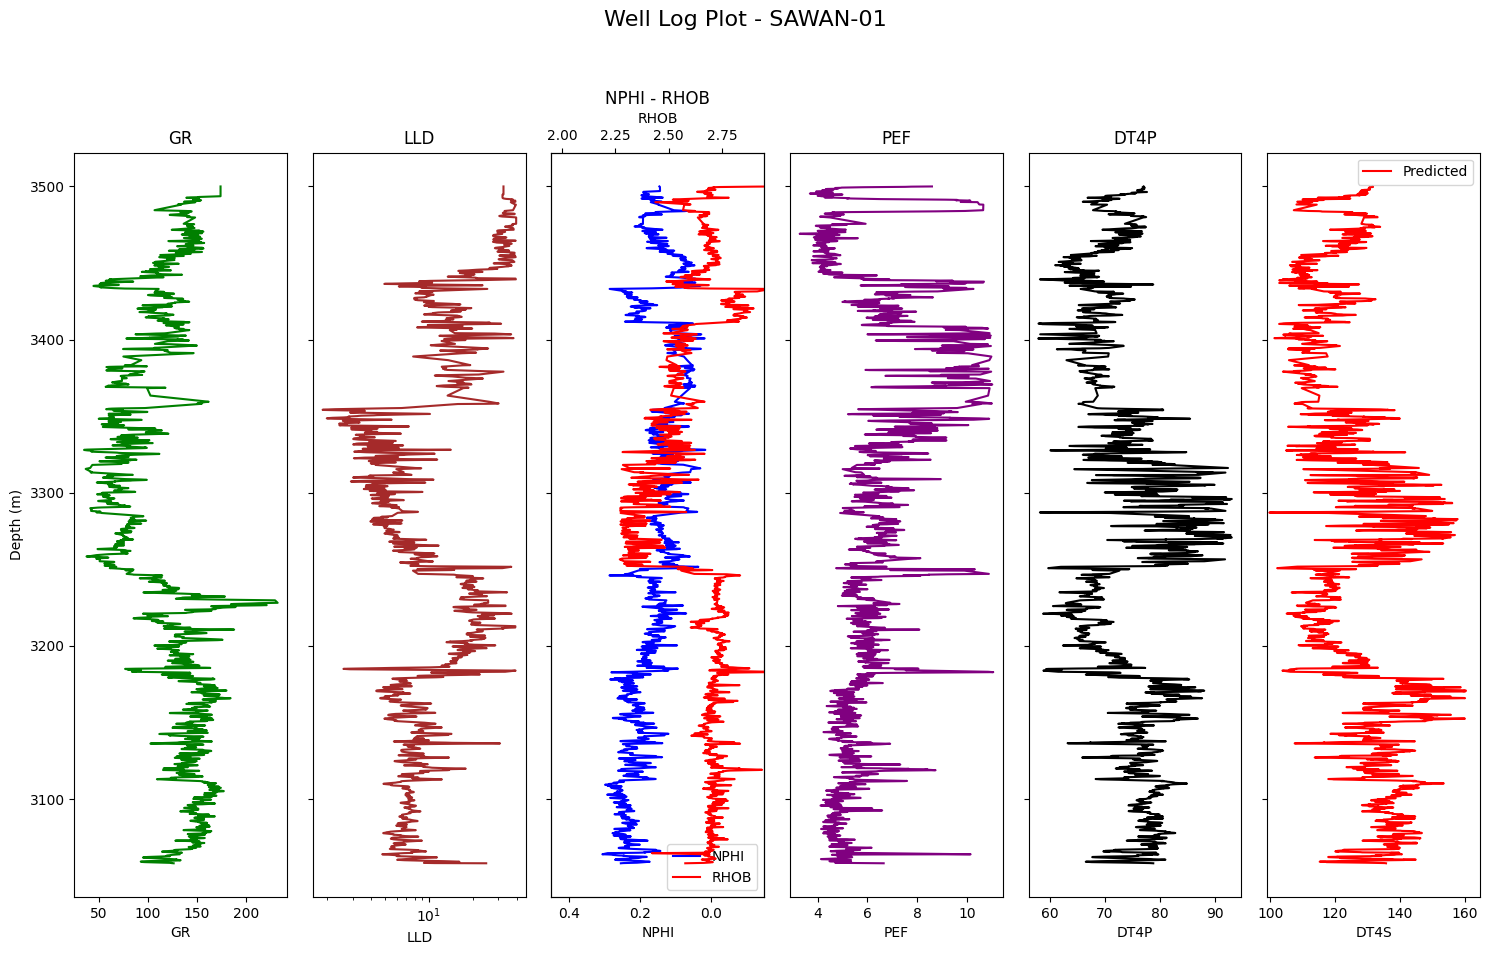

In [79]:
import matplotlib.pyplot as plt

def plot_logs1(df, well_name):
    fig, axes = plt.subplots(nrows=1, ncols=6, figsize=(15,10), sharey=True)

    depth = df["DEPT"]

    # Track 1: GR
    axes[0].plot(df["GR"], depth, color="green")
    axes[0].set_xlabel("GR")
    axes[0].set_title("GR")
    axes[0].invert_yaxis()

    # Track 2: LLD (semi-log)
    axes[1].semilogx(df["LLD"], depth, color="brown")
    axes[1].set_xlabel("LLD")
    axes[1].set_title("LLD")

    # Track 3: NPHI with twin RHOB
    ax3 = axes[2]
    ax3.plot(df["NPHI"], depth, color="blue", label="NPHI")
    ax3.set_xlim(0.45, -0.15)  # neutron porosity scale
    ax3.set_xlabel("NPHI")
    ax3.set_title("NPHI - RHOB")

    # Twin axis for RHOB
    ax3b = ax3.twiny()
    ax3b.plot(df["RHOB"], depth, color="red", label="RHOB")
    ax3b.set_xlim(1.95, 2.95)  # density scale
    ax3b.set_xlabel("RHOB")

    # Add legends for both axes
    l1, _ = ax3.get_legend_handles_labels()
    l2, _ = ax3b.get_legend_handles_labels()
    ax3.legend(l1 + l2, ["NPHI", "RHOB"], loc="lower right")

    # Track 4: PEF
    axes[3].plot(df["PEF"], depth, color="purple")
    axes[3].set_xlabel("PEF")
    axes[3].set_title("PEF")

    # Track 5: DT4P
    axes[4].plot(df["DT4P"], depth, color="black")
    axes[4].set_xlabel("DT4P")
    axes[4].set_title("DT4P")

    # Track 6: DT4S Actual & Predicted
    ax5 = axes[5]

    ax5.plot(df1_clean['DT4S_PRED'], df1_clean['DEPT'], color='red', linestyle='-', label='Predicted')
    ax5.set_xlabel("DT4S")
    ax5.set_xlim(df7_clean['DT4S'].min(), df7_clean['DT4S'].max())
    ax5.invert_yaxis()
    ax5.legend(loc='upper right')

    # Depth label
    fig.suptitle(f"Well Log Plot - {well_name}", fontsize=16)
    axes[0].set_ylabel("Depth (m)")

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


# Plot for wells 7 and 8
plot_logs1(df1_clean, "SAWAN-01")


In [81]:
# ✅ Save cleaned DataFrames with predictions to CSV
df1_clean.to_csv("SAWAN-01_clean.csv", index=False)
df7_clean.to_csv("SAWAN-07_clean.csv", index=False)
df8_clean.to_csv("SAWAN-08_clean.csv", index=False)

print("✅ CSV files saved: SAWAN-01_clean.csv, SAWAN-07_clean.csv, SAWAN-08_clean.csv")


✅ CSV files saved: SAWAN-01_clean.csv, SAWAN-07_clean.csv, SAWAN-08_clean.csv
